In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
# from common.trajectory_controller import TrajectoryController
# from common.activation_patcher import ActivationPatcher

#from analysis.utils import load_sweep_metadata, load_data

## Utils

In [11]:
def run_env_autonomous(env, initial_state, n_steps=100, is_rgb=False):

    obs_pixel_list = []
    obs_list = []
    if is_rgb:
        obs_pixel = env.reset(initial_state=initial_state)
        obs = env.get_state_obs()
        obs_pixel_list.append(obs_pixel)
        obs_list.append(obs)
    else:
        obs = env.reset(initial_state=initial_state)
        obs_list.append(obs)

    for _ in range(n_steps - 1):
        next_obs, reward, done, info = env.step(torch.tensor([0.0]))

        if is_rgb:
            obs_pixel_list.append(next_obs)
            obs_list.append(env.get_state_obs())
        else:
            obs_list.append(next_obs)

    if is_rgb:
        return np.array(obs_pixel_list), np.array(obs_list)
    else:
        return np.array(obs_list)


@torch.no_grad()
def run_dynamics_model(agent, env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    print(obs.shape)

    if obs.ndim == 3:
        obs = obs.unsqueeze(0)
    z = agent.model.encode(obs.to(agent.device), task=None).squeeze(0)
    obs_list = []
    obs_list.append(obs)
    z_list = []
    z_list.append(z.cpu().numpy())
    for _ in range(n_steps - 1):
        #next_obs, *_ = env.step(torch.tensor([0.0]))

        z = agent.model.next(z, torch.tensor([0.0]).to(agent.device), task=None)
        z_list.append(z.cpu().numpy())
        #obs_list.append(next_obs)

    return np.array(z_list)


@torch.no_grad()
def run_dynamics_model_in_steps(agent, env, initial_state, n_steps=100, k=10):
    obs = env.reset(initial_state=initial_state)

    if obs.ndim == 3:
        obs = obs.unsqueeze(0)
    z = agent.model.encode(obs.to(agent.device), task=None).squeeze(0)

    obs_list = []
    z_list = []
    obs_list.append(obs)
    z_list.append(z.cpu().numpy())
    for step in range(0, n_steps - 1, k):
        steps_in_chunk = min(k, n_steps - 1 - step)
        for _ in range(steps_in_chunk):

            next_obs, *_ = env.step(torch.tensor([0.0]))
            z = agent.model.next(z,
                                 torch.tensor([0.0]).to(agent.device),
                                 task=None)

            z_list.append(z.cpu().numpy())
            obs_list.append(next_obs)

        if next_obs.ndim == 3:
            next_obs = next_obs.unsqueeze(0)
        z = agent.model.encode(next_obs.to(agent.device), task=None).squeeze(0)
        #z_list.append(z.cpu().numpy())
    return np.array(z_list)

In [12]:
CKPT_TO_USE = 500_000

## Initialize environment and agent

In [13]:
# Base configuration for state-based environment
CKPT_TO_USE = 500_000
CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'
CKPT_PATH_RGB = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

override_cfg_rgb = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_RGB,
    obs='rgb',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create RGB-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_rgb = compose(config_name="config")
    OmegaConf.set_struct(cfg_rgb, False)
    cfg_rgb = OmegaConf.merge(cfg_rgb, override_cfg_rgb)

cfg_rgb = parse_cfg(cfg_rgb)
set_seed(cfg_rgb.seed)

cfg_rgb.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_rgb = make_env(cfg_rgb)

print("\nLoading RGB-based agent...")
agent_rgb = TDMPC2(cfg_rgb)
if hasattr(cfg_rgb, 'checkpoint') and cfg_rgb.checkpoint:
    print(f"Loading checkpoint: {cfg_rgb.checkpoint}")
    agent_rgb.load(cfg_rgb.checkpoint)

# Create state-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = TDMPC2(cfg_state)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


## Simulate autonomous data

In [14]:
def simulate_autonomous_data(env,
                             agent,
                             initial_positions=[0],
                             initial_angles=None,
                             steps_to_run=50):
    from itertools import product

    if initial_angles is None:
        initial_angles = np.linspace(0, 360, 11)
        print(initial_angles)
    obs = []
    z = []
    for initial_position, initial_angle in tqdm(
            product(initial_positions, initial_angles)):
        initial_angle_radians = np.radians(initial_angle)
        initial_state = {
            'qpos': {
                'slider': initial_position,  #cart position
                'hinge_1': initial_angle_radians,  # pole angle
            },
            'qvel': {
                #'slider': 0,  #cart velocity
                #'hinge_1': 0,  # pole angular velocity
            }
        }

        obs_true = run_env_autonomous(env, initial_state, steps_to_run)
        z_true = agent.model.encode(torch.from_numpy(obs_true).to(agent.device),
                                    task=None).detach().cpu().numpy()

        obs.append(obs_true)
        z.append(z_true)

    return np.concatenate(obs), np.concatenate(z)


obs_autonomous, z_autonomous = simulate_autonomous_data(
    env_state,
    agent_state,
    initial_positions=[-1, 0, 1],
    initial_angles=None,
    steps_to_run=50)

[  0.  36.  72. 108. 144. 180. 216. 252. 288. 324. 360.]


0it [00:00, ?it/s]

33it [00:00, 53.07it/s]


In [15]:
def simulate_autonomous_data(
    env,
    initial_positions=[0],
    initial_angles=None,
    steps_to_run=50,
):
    from itertools import product

    if initial_angles is None:
        initial_angles = np.linspace(0, 360, 11)
        print(initial_angles)
    results = {}
    for initial_position, initial_angle in tqdm(
            product(initial_positions, initial_angles)):
        initial_angle_radians = np.radians(initial_angle)
        initial_state = {
            'qpos': {
                'slider': initial_position,  # cart position
                'hinge_1': initial_angle_radians,  # pole angle
            },
            'qvel': {
                # Optionally add 'slider': 0, 'hinge_1': 0 if needed
            }
        }

        obs_true = run_env_autonomous(env, initial_state, steps_to_run)
        key = (initial_position, initial_angle)
        results[key] = obs_true

    return results


obs_autonomous = simulate_autonomous_data(env_state,
                                          initial_positions=[-1, 0, 1],
                                          initial_angles=None,
                                          steps_to_run=200)

[  0.  36.  72. 108. 144. 180. 216. 252. 288. 324. 360.]


33it [00:02, 14.84it/s]


In [16]:
obs_autonomous.keys()

dict_keys([(-1, 0.0), (-1, 36.0), (-1, 72.0), (-1, 108.0), (-1, 144.0), (-1, 180.0), (-1, 216.0), (-1, 252.0), (-1, 288.0), (-1, 324.0), (-1, 360.0), (0, 0.0), (0, 36.0), (0, 72.0), (0, 108.0), (0, 144.0), (0, 180.0), (0, 216.0), (0, 252.0), (0, 288.0), (0, 324.0), (0, 360.0), (1, 0.0), (1, 36.0), (1, 72.0), (1, 108.0), (1, 144.0), (1, 180.0), (1, 216.0), (1, 252.0), (1, 288.0), (1, 324.0), (1, 360.0)])

In [17]:
from analysis.utils import reconstruct_cartpole_dmcontrol

reconstruct_cartpole_dmcontrol(obs_autonomous[(-1, 180)], show=True)


100%|██████████| 200/200 [00:04<00:00, 46.66it/s]
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/imageio_ffmpeg/_utils.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [65]:
import pickle

with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_autonomous_dynamics/obs_autonomous_200.pkl',
        'wb') as f:
    pickle.dump(obs_autonomous, f)

## Load probe

### nonlinear

In [18]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = 512
output_dim = 5
hd = 256

# Load the model directly instead of loading state_dict
nonlinear_probe = torch.load(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_pixel_vs_state/mlp_model_pixel_vs_state.pth',
    weights_only=False,
    map_location=device)
nonlinear_probe = nonlinear_probe.to(device)

### linear probe

In [19]:
from analysis.utils import load_sweep_metadata, load_data

df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

df['ckpt_int'] = df['checkpoint'].apply(
    lambda x: int(x.split('/')[-1].split('.')[0]))

df = df[df['ckpt_int'] == CKPT_TO_USE]
z_nonautonomous = np.concatenate(df['latent_states'].tolist())
obs_nonautonomous = np.concatenate(df['observations'].tolist())

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 332.73it/s]


Found 108 configurations
Found 108 configurations


100%|██████████| 108/108 [00:03<00:00, 30.67it/s]


In [20]:
# Collect all latents and observations
all_latents = []
all_observations = []

# Concatenate all |episodes
#X = np.concatenate([z_autonomous, z_nonautonomous])
#y = np.concatenate([obs_autonomous, obs_nonautonomous])

X = z_nonautonomous
y = obs_nonautonomous

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

# Fit linear probe for each observation dimension
linear_probe = LinearRegression()
linear_probe.fit(X_train, y_train)
y_pred = linear_probe.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R²: {np.mean(r2):.4f}")

R²: 1.0000


In [21]:
# initial_state = {
#     'qpos': {
#         'slider': 0.,  # cart position
#         'hinge_1': 0.,  # pole angle
#     },
#     'qvel': {
#         'slider': 0,  # cart velocity
#         'hinge_1': 0,  # pole angular velocity
#     }
# }

# obs_true_pixel, obs_true_state = run_env_autonomous(
#     env_rgb,
#     #initial_state,
#     50,
#     is_rgb=True)

In [22]:
obs_true_pixel.shape

NameError: name 'obs_true_pixel' is not defined

In [23]:
def evaluate_autonomous_rollouts(agent,
                                 env,
                                 probe,
                                 intital_positions=[0],
                                 initial_angles=np.linspace(0, 360, 11)[1:-1],
                                 steps_to_run=200,
                                 is_rgb=False):
    """
    Run autonomous rollouts for combinations of positions and angles, 
    compute ground-truth and predicted latent/physical states, errors, and R2, 
    and aggregate results for further analysis.

    Returns:
        results: dict keyed by (initial_position, initial_angle)
    """
    results = {}
    for initial_position, initial_angle in tqdm(
            product(intital_positions, initial_angles)):
        initial_angle_radians = np.radians(initial_angle)
        initial_state = {
            'qpos': {
                'slider': initial_position,  # cart position
                'hinge_1': initial_angle_radians,  # pole angle
            },
            'qvel': {
                'slider': 0,  # cart velocity
                'hinge_1': 0,  # pole angular velocity
            }
        }

        if is_rgb:
            obs_true_pixel, obs_true_state = run_env_autonomous(env,
                                                                initial_state,
                                                                steps_to_run,
                                                                is_rgb=is_rgb)
            z_true = agent.model.encode(torch.from_numpy(obs_true_pixel).to(
                agent.device),
                                        task=None).detach().cpu().numpy()
        else:
            obs_true_state = run_env_autonomous(env, initial_state,
                                                steps_to_run)
            z_true = agent.model.encode(torch.from_numpy(obs_true_state).to(
                agent.device),
                                        task=None).detach().cpu().numpy()

        z_predicted = run_dynamics_model(agent, env, initial_state,
                                         steps_to_run)

        if is_rgb:
            obs_predicted = probe(torch.from_numpy(z_predicted).to(
                'cuda')).detach().cpu().numpy()
        else:
            obs_predicted = probe.predict(z_predicted)

        dict_results_steps = {}
        for k in list(range(1, 10 + 1)) + [20] + [30] + [40] + [50]:
            z_predicted_steps = run_dynamics_model_in_steps(
                agent, env, initial_state, n_steps=steps_to_run, k=k)

            if is_rgb:
                obs_predicted_steps = probe(
                    torch.from_numpy(z_predicted_steps).to(
                        'cuda')).detach().cpu().numpy()
            else:
                obs_predicted_steps = probe.predict(z_predicted_steps)

            dict_results_steps[f'z_predicted_steps_{k}'] = z_predicted_steps
            #dict_results_steps[f'obs_true_steps_{k}'] = obs_true_steps
            dict_results_steps[f'obs_predicted_steps_{k}'] = obs_predicted_steps

        errors_latent = (abs(z_true - z_predicted)).mean(1)
        errors_physical = (abs(obs_true_state - obs_predicted)).mean(1)
        error_physical_per_dim = [
            (abs(obs_true_state[:, i] - obs_predicted[:, i])).mean()
            for i in range(5)
        ]
        error_latent_per_dim = [
            (abs(z_true[:, i] - z_predicted[:, i])).mean() for i in range(512)
        ]
        r2_physical = r2_score(obs_true_state, obs_predicted)
        r2_physical_per_dim = [
            r2_score(obs_true_state[:, i], obs_predicted[:, i])
            for i in range(5)
        ]
        r2_latent = r2_score(z_true, z_predicted)
        r2_latent_per_dim = [
            r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
        ]

        r2_latent_per_time = [
            r2_score(z_true[t, :], z_predicted[t, :])
            for t in range(steps_to_run)
        ]
        variance_z_true_per_dim = np.var(z_true, axis=0)
        variance_z_predicted_per_dim = np.var(z_predicted, axis=0)
        variance_obs_true_per_dim = np.var(obs_true_state, axis=0)
        variance_obs_predicted_per_dim = np.var(obs_predicted, axis=0)

        results[(initial_position, initial_angle)] = {
            'obs_true_state': obs_true_state,
            'obs_true_pixel': obs_true_pixel if is_rgb else None,
            'obs_predicted': obs_predicted,
            'z_true': z_true,
            'z_predicted': z_predicted,
            **dict_results_steps,
            'errors_latent': errors_latent,
            'errors_physical': errors_physical,
            'error_physical_per_dim': error_physical_per_dim,
            'error_latent_per_dim': error_latent_per_dim,
            'r2_physical': r2_physical,
            'r2_physical_per_dim': r2_physical_per_dim,
            'r2_latent_per_time': r2_latent_per_time,
            'r2_latent': r2_latent,
            'r2_latent_per_dim': r2_latent_per_dim,
            'variance_z_true_per_dim': variance_z_true_per_dim,
            'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
            'variance_obs_true_per_dim': variance_obs_true_per_dim,
            'variance_obs_predicted_per_dim': variance_obs_predicted_per_dim,
        }
    return results

In [24]:
results_state = evaluate_autonomous_rollouts(agent_state,
                                             env_state,
                                             linear_probe,
                                             is_rgb=False)
results_rgb = evaluate_autonomous_rollouts(agent_rgb,
                                           env_rgb,
                                           nonlinear_probe,
                                           is_rgb=True)


0it [00:00, ?it/s]

torch.Size([5])


1it [00:02,  2.61s/it]

torch.Size([5])


2it [00:05,  2.51s/it]

...

7it [04:03, 35.07s/it]

torch.Size([9, 64, 64])


8it [04:39, 35.42s/it]

torch.Size([9, 64, 64])


9it [05:15, 35.08s/it]


## Test probes

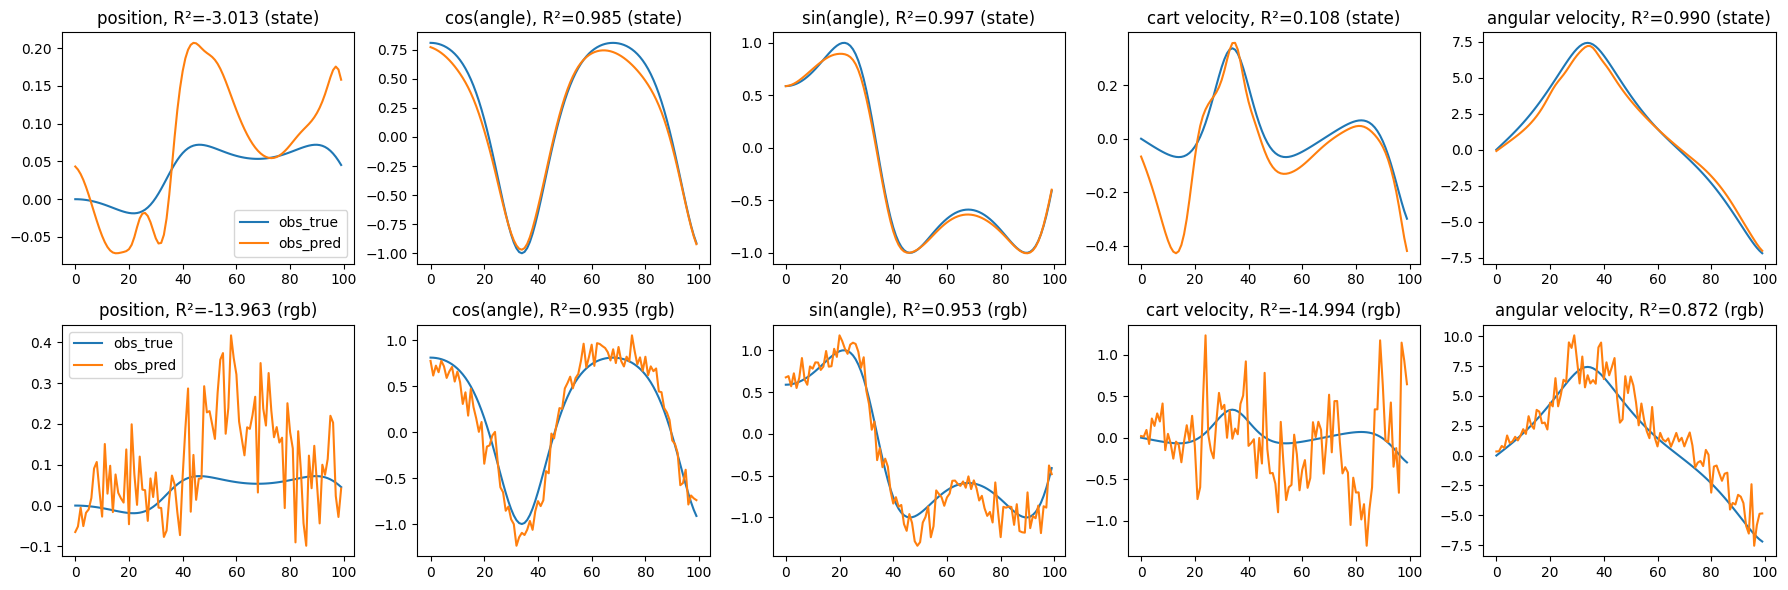

In [25]:
# Plot state (linear probe, first row) and rgb (nonlinear probe, second row) for first 2 episodes

z_true_all_state = []
obs_true_all_state = []
z_true_all_rgb = []
obs_true_all_rgb = []

for key in results_state.keys():
    z_true_all_state.append(results_state[key]['z_true'])
    obs_true_all_state.append(results_state[key]['obs_true_state'])

for key in results_rgb.keys():
    z_true_all_rgb.append(results_rgb[key]['z_true'])
    obs_true_all_rgb.append(results_rgb[key]['obs_true_state'])

z_true_stacked_state = np.vstack(z_true_all_state)
obs_true_stacked_state = np.vstack(obs_true_all_state)

z_true_stacked_rgb = np.vstack(z_true_all_rgb)
obs_true_stacked_rgb = np.vstack(obs_true_all_rgb)

# Predict (state: linear, rgb: nonlinear)
obs_pred_stacked_state = linear_probe.predict(z_true_stacked_state)
obs_pred_stacked_rgb = nonlinear_probe(
    torch.from_numpy(z_true_stacked_rgb).to('cuda')).detach().cpu().numpy()

episodes_to_plot = 2

map_name = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for dim in range(5):
    # State/linear, first row
    r2_linear = r2_score(obs_true_stacked_state[:episodes_to_plot * 50, dim],
                         obs_pred_stacked_state[:episodes_to_plot * 50, dim])
    axes[0, dim].plot(obs_true_stacked_state[:episodes_to_plot * 50, dim],
                      label='obs_true')
    axes[0, dim].plot(obs_pred_stacked_state[:episodes_to_plot * 50, dim],
                      label='obs_pred')
    axes[0, dim].set_title(f'{map_name[dim]}, R²={r2_linear:.3f} (state)')
    if dim == 0:
        axes[0, dim].legend()

    # RGB/nonlinear, second row
    r2_nonlinear = r2_score(obs_true_stacked_rgb[:episodes_to_plot * 50, dim],
                            obs_pred_stacked_rgb[:episodes_to_plot * 50, dim])
    axes[1, dim].plot(obs_true_stacked_rgb[:episodes_to_plot * 50, dim],
                      label='obs_true')
    axes[1, dim].plot(obs_pred_stacked_rgb[:episodes_to_plot * 50, dim],
                      label='obs_pred')
    axes[1, dim].set_title(f'{map_name[dim]}, R²={r2_nonlinear:.3f} (rgb)')
    if dim == 0:
        axes[1, dim].legend()

plt.tight_layout()
plt.show()

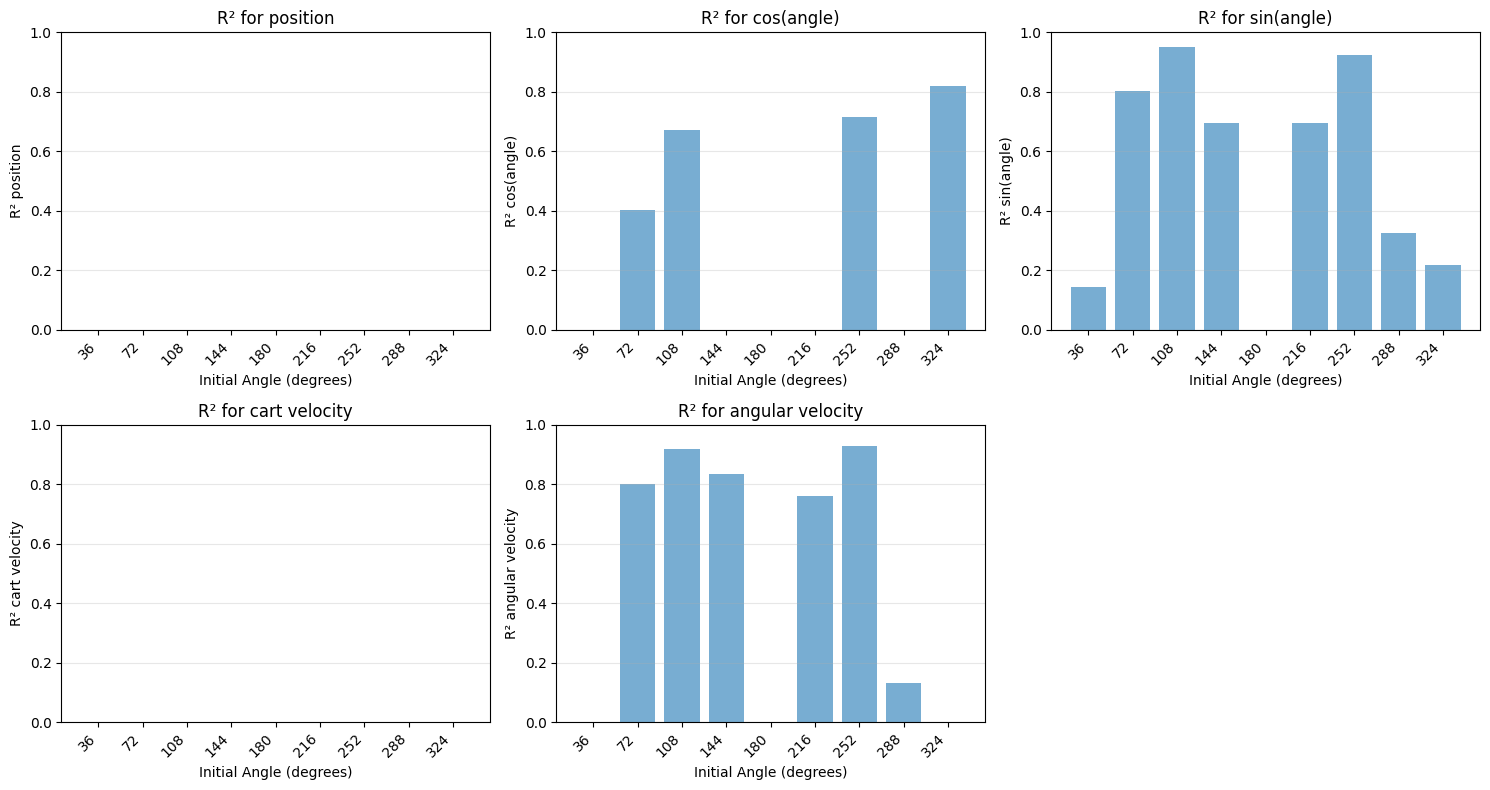

In [26]:
# Plot R² physical per dimension for each initial condition
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    initial_angles_list = []
    r2_physical_per_dim_list = []

    for (initial_position, initial_angle), result in results_state.items():
        initial_angles_list.append(initial_angle)
        r2_physical_per_dim_list.append(result['r2_physical_per_dim'][dim])

    ax = axes[dim]
    ax.bar(range(len(initial_angles_list)), r2_physical_per_dim_list, alpha=0.6)
    ax.set_xlabel('Initial Angle (degrees)')
    ax.set_ylabel(f'R² {variable_names[dim]}')
    ax.set_ylim(0, 1)
    ax.set_title(f'R² for {variable_names[dim]}')
    ax.set_xticks(range(len(initial_angles_list)))
    ax.set_xticklabels([f'{angle:.0f}' for angle in initial_angles_list],
                       rotation=45,
                       ha='right')
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


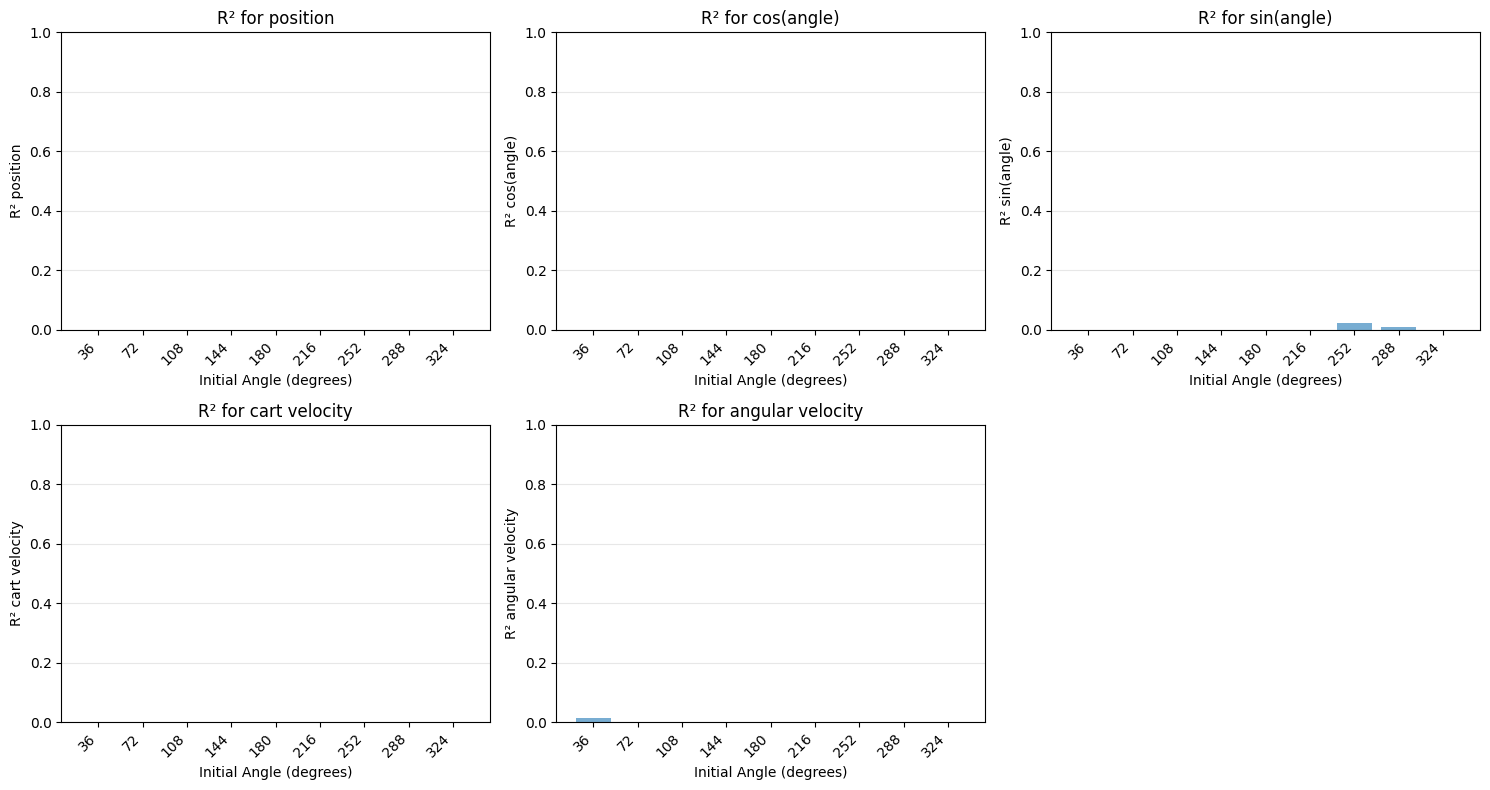

In [27]:
# Plot R² physical per dimension for each initial condition
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    initial_angles_list = []
    r2_physical_per_dim_list = []

    for (initial_position, initial_angle), result in results_rgb.items():
        initial_angles_list.append(initial_angle)
        r2_physical_per_dim_list.append(result['r2_physical_per_dim'][dim])

    ax = axes[dim]
    ax.bar(range(len(initial_angles_list)), r2_physical_per_dim_list, alpha=0.6)
    ax.set_xlabel('Initial Angle (degrees)')
    ax.set_ylabel(f'R² {variable_names[dim]}')
    ax.set_ylim(0, 1)
    ax.set_title(f'R² for {variable_names[dim]}')
    ax.set_xticks(range(len(initial_angles_list)))
    ax.set_xticklabels([f'{angle:.0f}' for angle in initial_angles_list],
                       rotation=45,
                       ha='right')
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

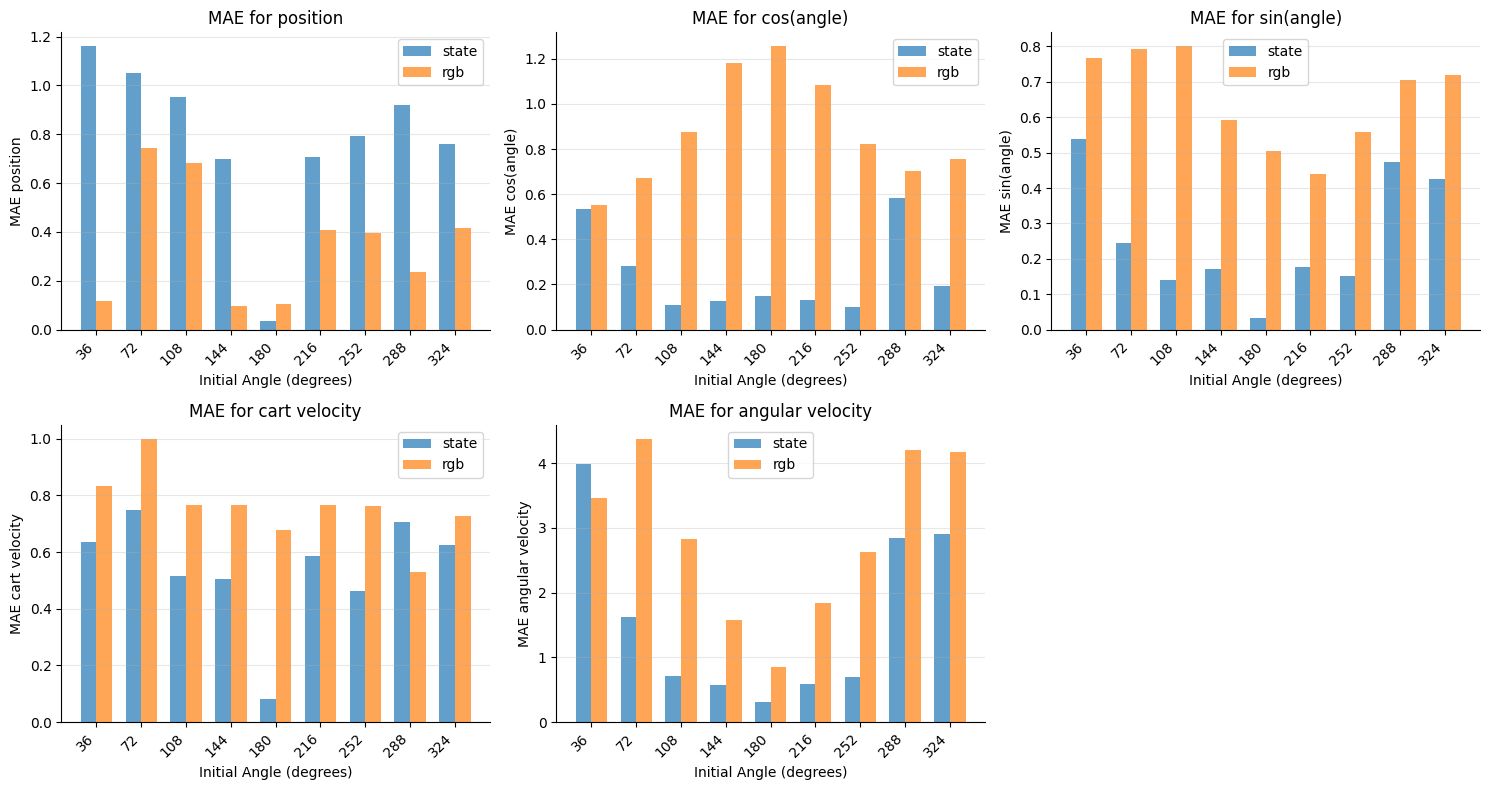

In [28]:
# Plot MAE physical per dimension for each initial condition: state vs rgb, one bar for each

variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Assume initial_conditions are the same for both modalities and sorted equivalently
initial_conditions = sorted(
    results_state.keys())  # Should be (initial_position, initial_angle)
initial_angles_list = [angle for (_, angle) in initial_conditions]

for dim in range(5):
    mae_state = []
    mae_rgb = []

    for cond in initial_conditions:
        mae_state.append(results_state[cond]['error_physical_per_dim'][dim])
        mae_rgb.append(results_rgb[cond]['error_physical_per_dim'][dim])

    ax = axes[dim]
    x = np.arange(len(initial_angles_list))
    width = 0.35

    ax.bar(x - width / 2, mae_state, width, label='state', alpha=0.7)
    ax.bar(x + width / 2, mae_rgb, width, label='rgb', alpha=0.7)

    ax.set_xlabel('Initial Angle (degrees)')
    ax.set_ylabel(f'MAE {variable_names[dim]}')
    ax.set_title(f'MAE for {variable_names[dim]}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{angle:.0f}' for angle in initial_angles_list],
                       rotation=45,
                       ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()


## Latent R2

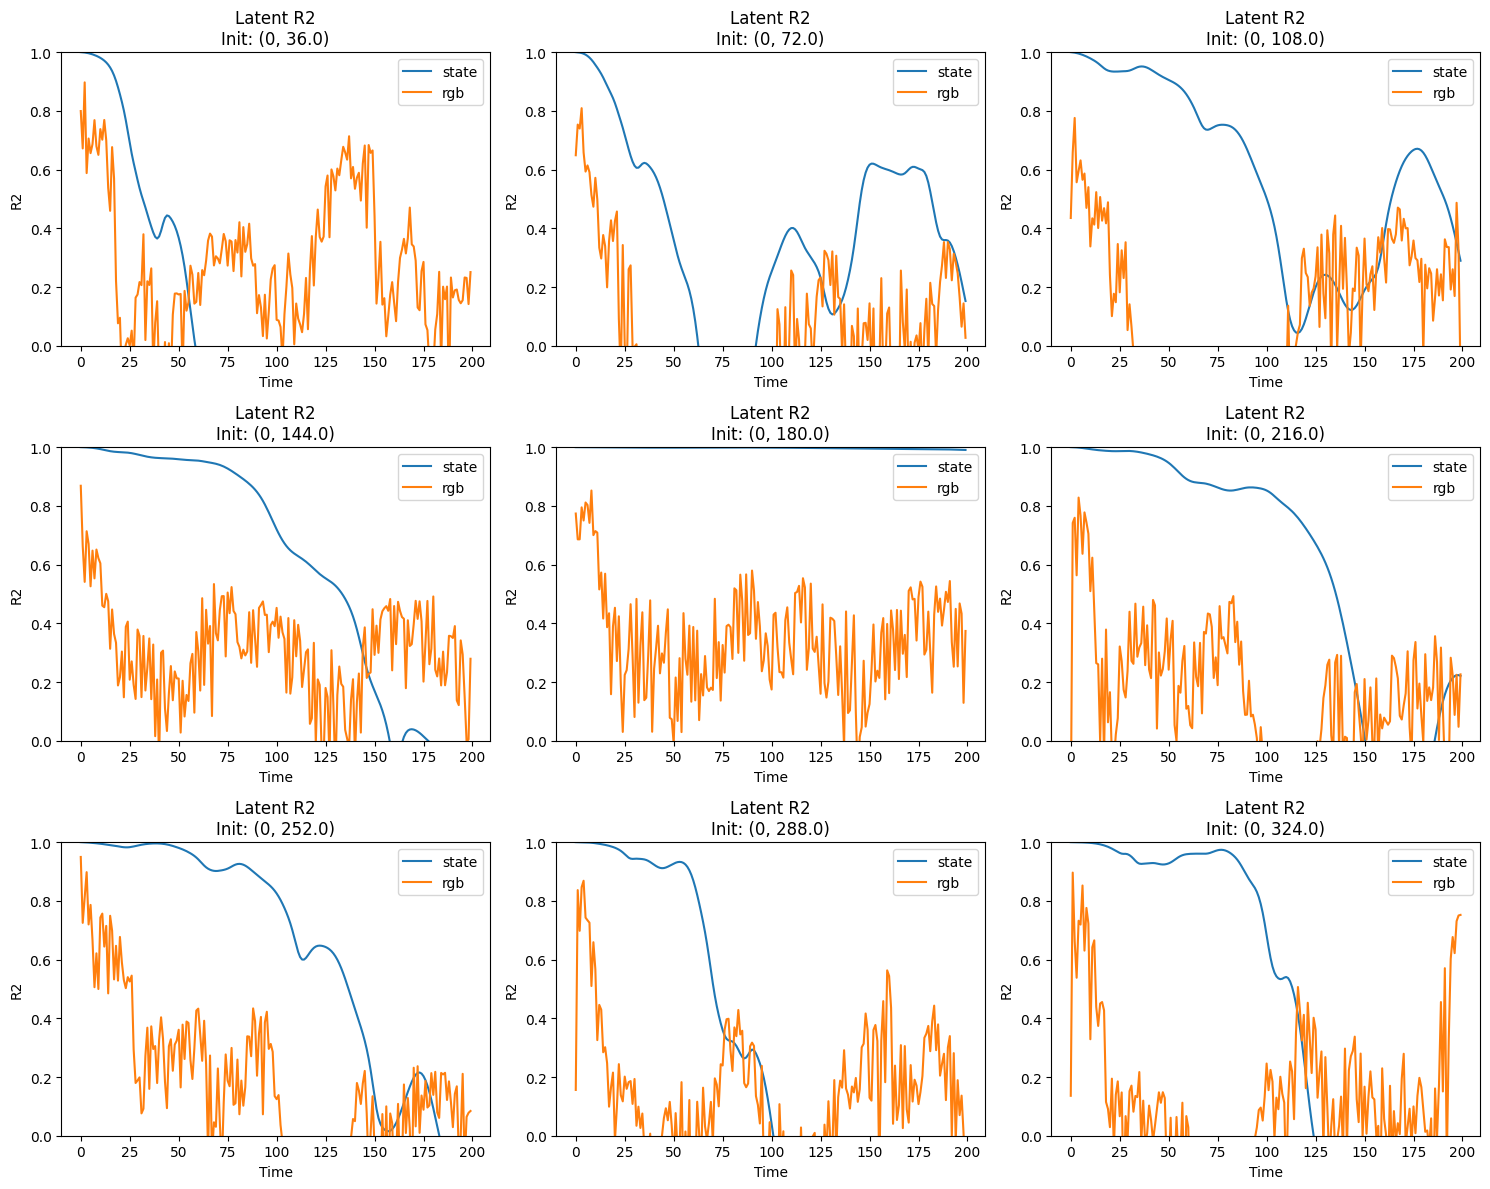

In [29]:
# Plot all initial condition R2 curves, 3 plots per row in a grid
initial_conditions = sorted(results_state.keys())
n_conds = len(initial_conditions)
ncols = 3
nrows = (n_conds + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, cond in enumerate(initial_conditions):
    ax = axes[i]
    ax.plot(results_state[cond]['r2_latent_per_time'], label='state')
    ax.plot(results_rgb[cond]['r2_latent_per_time'], label='rgb')
    ax.set_title(f'Latent R2\nInit: {cond}')
    ax.set_xlabel('Time')
    ax.set_ylabel('R2')
    ax.set_ylim(0, 1)
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## Add comparison with dreamer

In [30]:
import pickle

dreamer_results_path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/results_dynamics/results_dreamer_dynamics_state.pkl"
with open(dreamer_results_path, "rb") as f:
    results_dreamer_state = pickle.load(f)

dreamer_pixel_results_path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/results_dynamics/results_dreamer_dynamics_pixel.pkl"
with open(dreamer_pixel_results_path, "rb") as f:
    results_dreamer_pixel = pickle.load(f)


In [31]:
results_dreamer_state.keys()

dict_keys([(0, 36.0), (0, 72.0), (0, 108.0), (0, 144.0), (0, 180.0), (0, 216.0), (0, 252.0), (0, 288.0), (0, 324.0)])

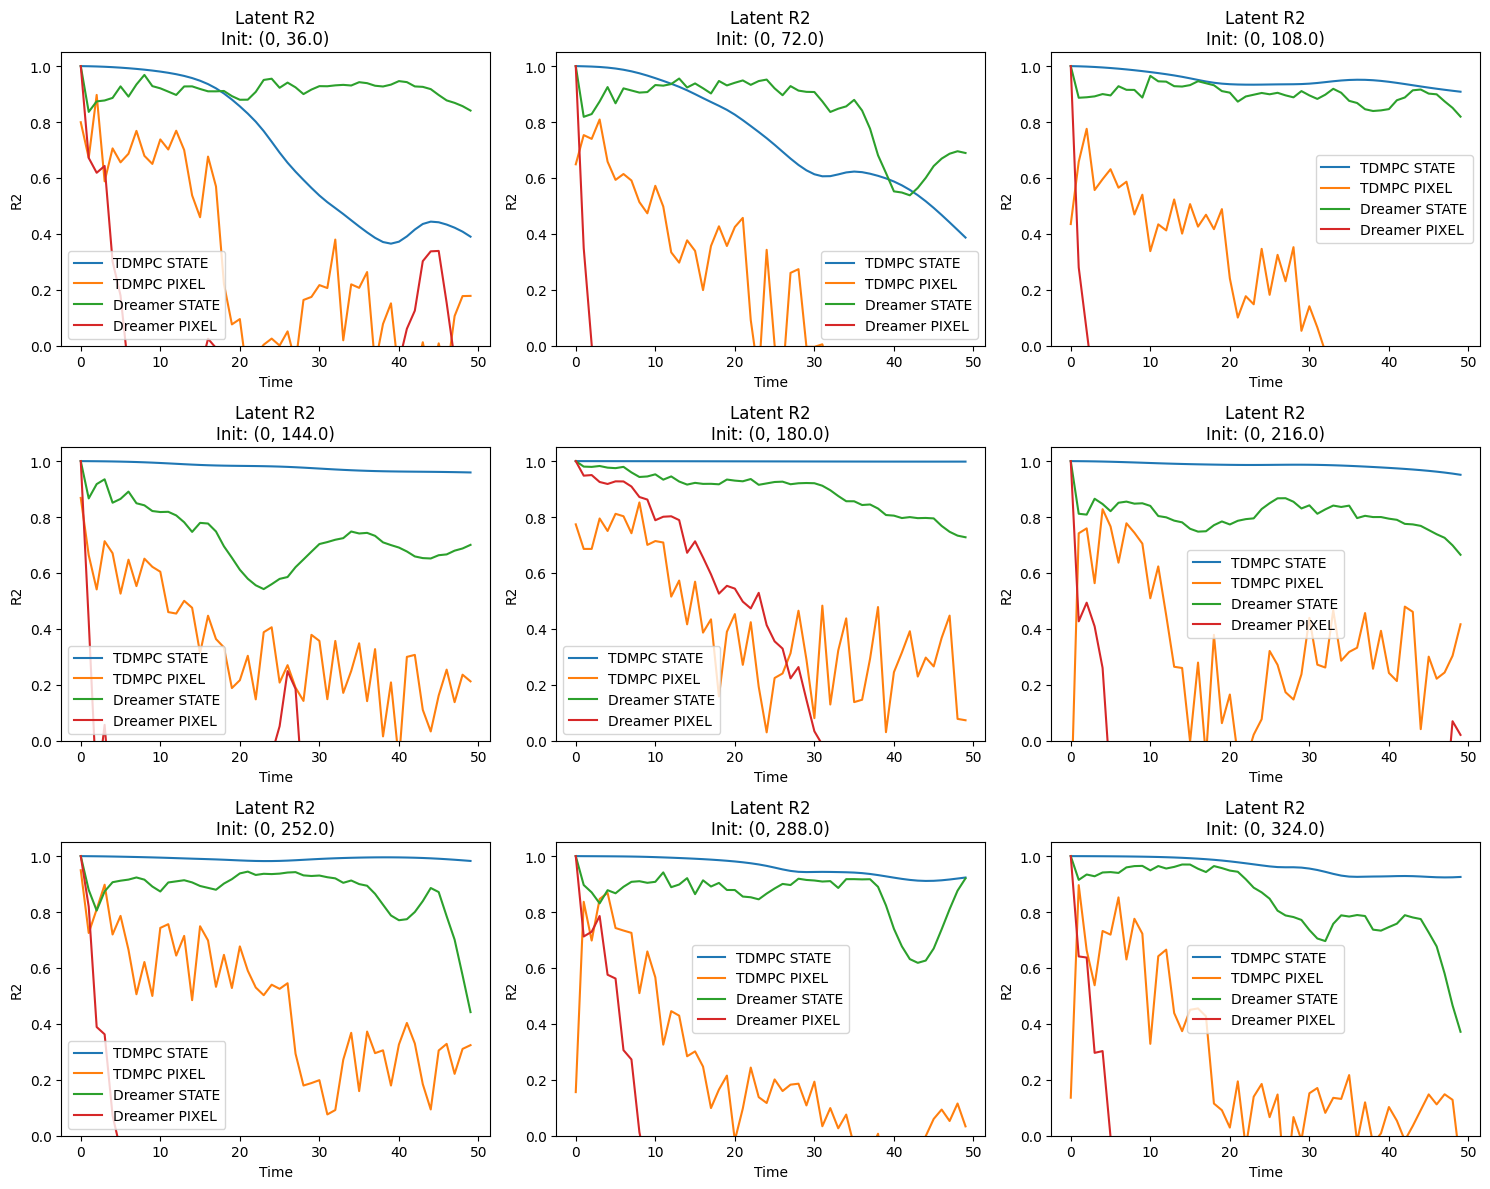

In [33]:
# Plot all initial condition R2 curves, 3 plots per row in a grid
initial_conditions = sorted(results_state.keys())
n_conds = len(initial_conditions)
ncols = 3
nrows = (n_conds + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, cond in enumerate(initial_conditions):
    ax = axes[i]
    ax.plot(results_state[cond]['r2_latent_per_time'][:50], label='TDMPC STATE')
    ax.plot(results_rgb[cond]['r2_latent_per_time'][:50], label='TDMPC PIXEL')
    ax.plot(results_dreamer_state[cond]['r2_latent_per_time_stoch'][:50],
            label='Dreamer STATE')
    ax.plot(results_dreamer_pixel[cond]['r2_latent_per_time_stoch'][:50],
            label='Dreamer PIXEL')
    ax.set_title(f'Latent R2\nInit: {cond}')
    ax.set_xlabel('Time')
    ax.set_ylabel('R2')
    ax.set_ylim(0, 1.05)
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [120]:
# _ = reconstruct_cartpole_dmcontrol(
#     results[(0, 324)]['obs_true'],
#     save_video=True,
#     out_path=
#     f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_true_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
# )

# _ = reconstruct_cartpole_dmcontrol(
#     results[(0, 288)]['obs_predicted'],
#     save_video=True,
#     out_path=
#     f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_steps_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
# )

In [121]:
# obs_predicted_with_true_positions = results[(0, 108)]['obs_predicted']
# obs_predicted_with_true_positions[:, 0] = results[(0, 108)]['obs_true'][:, 0]
# reconstruct_cartpole_dmcontrol(
#     #results[(0, 324)]['obs_predicted'],
#     obs_predicted_with_true_positions,
#     save_video=True,
#     out_path=
#     f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
# )

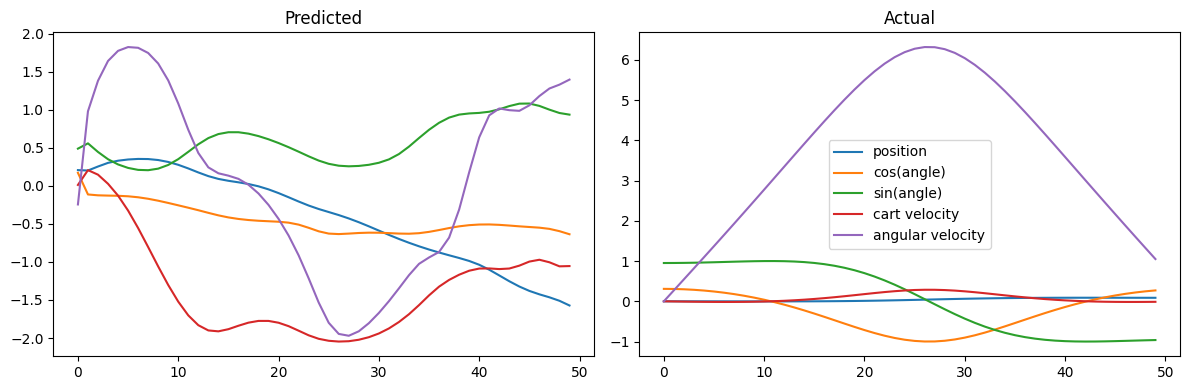

In [97]:
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

steps_to_plot = 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for i in range(5):
    ax1.plot(results_rgb[(0, 72)]['obs_predicted'][:steps_to_plot, i],
             label=variable_names[i])
ax1.set_title('Predicted')

for i in range(5):
    ax2.plot(results_rgb[(0, 72)]['obs_true_state'][:steps_to_plot, i],
             label=variable_names[i])
ax2.set_title('Actual')
plt.legend()
plt.tight_layout()

In [123]:
# errors_latent = ((z_true - z_predicted)**2).mean(1)
# errors_physical = ((obs_true - obs_predicted)**2).mean(1)

# r2_physical = r2_score(obs_true[:steps_to_plot], obs_predicted[:steps_to_plot])

# r2_physical_per_dim = [
#     r2_score(obs_true[:steps_to_plot, i], obs_predicted[:steps_to_plot, i])
#     for i in range(5)
# ]
# r2_latent = r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
# r2_latent_per_dim = [
#     r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
#     for i in range(512)
# ]

# variance_per_dim = np.var(z_true[:steps_to_plot], axis=0)

# r2_physical = r2_score(obs_true[:steps_to_plot], obs_predicted[:steps_to_plot])

# r2_physical_per_dim = [
#     r2_score(obs_true[:steps_to_plot, i], obs_predicted[:steps_to_plot, i])
#     for i in range(5)
# ]
# r2_latent = r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
# r2_latent_per_dim = [
#     r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
#     for i in range(512)
# ]

# variance_per_dim = np.var(z_true[:steps_to_plot], axis=0)

# sorted_variance = sorted(variance_per_dim, reverse=True)

# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(sorted_variance, linewidth=2, color='steelblue', alpha=0.8)
# ax.set_xlabel('Latent Dimension (sorted by variance)', fontsize=12)
# ax.set_ylabel('Variance', fontsize=12)
# ax.set_title('Variance per Latent Dimension (Sorted)',
#              fontsize=14,
#              fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')
# plt.tight_layout()
# plt.show()

In [124]:
# fig, ax = plt.subplots(figsize=(12, 5))

# # Sort R² scores by magnitude
# sorted_r2 = sorted(r2_latent_per_dim, reverse=True)

# ax.plot(sorted_r2, linewidth=2, color='steelblue', alpha=0.8)
# ax.set_ylim(0, 1)
# ax.set_xlabel('Latent Dimension (sorted by R²)', fontsize=12)
# ax.set_ylabel('R² Score', fontsize=12)
# ax.set_title('R² Score per Latent Dimension (Sorted)',
#              fontsize=14,
#              fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')

# # # Plot red dots at y=0 for dimensions with R² < 1
# # low_r2_count = sum(1 for r2 in sorted_r2 if r2 < 1)
# # if low_r2_count > 0:
# #     low_r2_indices = [i for i, r2 in enumerate(sorted_r2) if r2 < 1]
# #     ax.scatter(low_r2_indices, [0] * len(low_r2_indices),
# #                color='red',
# #                s=20,
# #                alpha=0.6,
# #                label=f'R² < 1 ({low_r2_count} dims)',
# #                zorder=5)
# #     ax.legend()

# plt.tight_layout()
# plt.show()

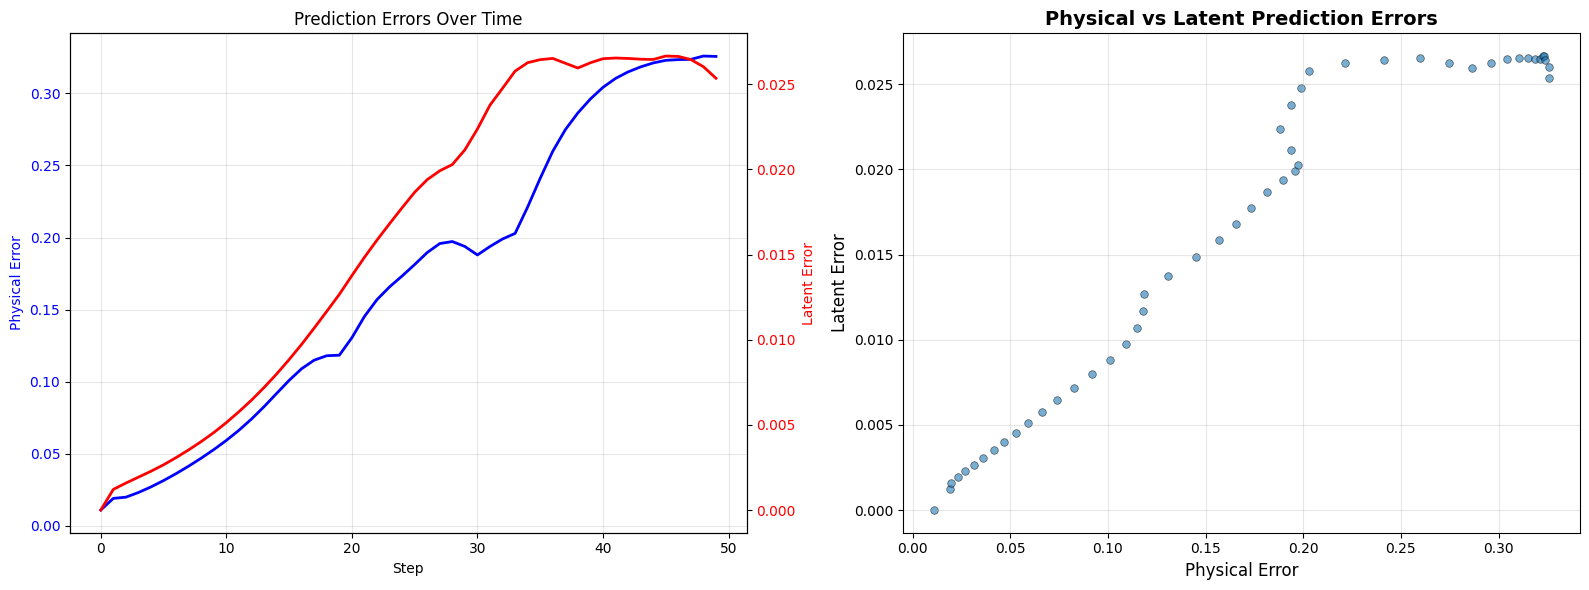

In [125]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Time series of errors with dual y-axes
ax1_left = ax1
ax1_left.plot(errors_physical, 'b-', label='Physical', linewidth=2)
ax1_left.set_xlabel('Step')
ax1_left.set_ylabel('Physical Error', color='b')
ax1_left.tick_params(axis='y', labelcolor='b')
ax1_left.grid(True, alpha=0.3)

# Create second y-axis for latent errors
ax1_right = ax1.twinx()
ax1_right.plot(errors_latent, 'r-', label='Latent', linewidth=2)
ax1_right.set_ylabel('Latent Error', color='r')
ax1_right.tick_params(axis='y', labelcolor='r')

ax1.set_title('Prediction Errors Over Time')

# Right plot: Scatter plot
ax2.scatter(errors_physical,
            errors_latent,
            alpha=0.6,
            s=30,
            edgecolors='k',
            linewidth=0.5)
ax2.set_xlabel('Physical Error', fontsize=12)
ax2.set_ylabel('Latent Error', fontsize=12)
ax2.set_title('Physical vs Latent Prediction Errors',
              fontsize=14,
              fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis of the dynamcis with predicted steps

In [101]:
angle_to_analyze = 324

In [107]:
# Store results for each prediction horizon
prediction_horizons = list(range(1, 10 + 1)) + [20] + [30] + [40] + [50]
metrics_by_horizon = {}

results = results_rgb
z_true = results_rgb[(0, angle_to_analyze)]['z_true']

for horizon in prediction_horizons:
    z_pred = results[(0, angle_to_analyze)][f'z_predicted_steps_{horizon}']
    obs_pred = results[(0, angle_to_analyze)][f'obs_predicted_steps_{horizon}']
    obs_true = results[(0, angle_to_analyze)][f'obs_true_state']

    errors_latent = (abs(z_true - z_pred)).mean(1)
    errors_physical = (abs(obs_true - obs_pred)).mean(1)
    error_physical_per_dim = [
        (abs(obs_true[:, i] - obs_pred[:, i])).mean() for i in range(5)
    ]
    error_latent_per_dim = [
        (abs(z_true[:, i] - z_pred[:, i])).mean() for i in range(512)
    ]
    r2_physical = r2_score(obs_true, obs_pred)
    r2_physical_per_dim = [
        r2_score(obs_true[:, i], obs_pred[:, i]) for i in range(5)
    ]
    r2_latent = r2_score(z_true, z_pred)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_pred[:, i]) for i in range(512)
    ]
    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_pred, axis=0)

    metrics_by_horizon[horizon] = {
        'errors_latent': errors_latent,
        'errors_physical': errors_physical,
        'error_physical_per_dim': error_physical_per_dim,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_physical': r2_physical,
        'r2_physical_per_dim': r2_physical_per_dim,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim
    }

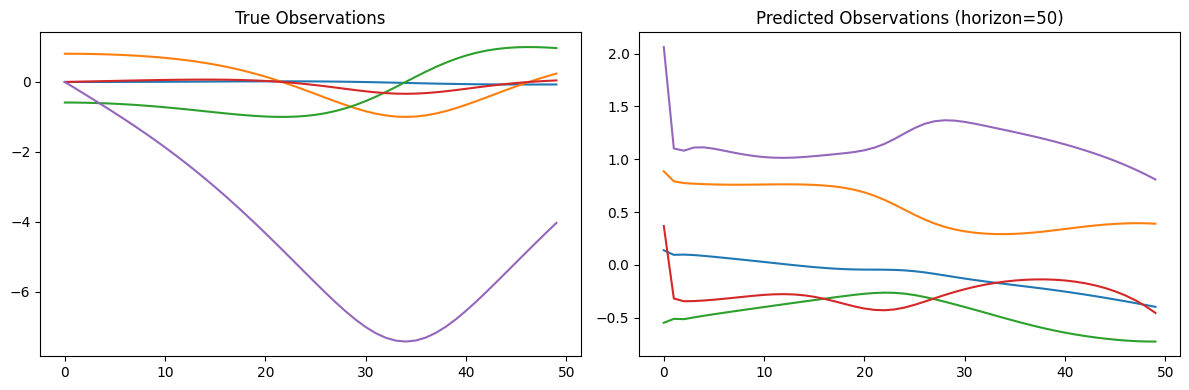

In [104]:
horizon = 50
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(obs_true)
axes[0].set_title('True Observations')
axes[1].plot(results[(0, angle_to_analyze)][f'obs_predicted_steps_{horizon}'])
axes[1].set_title(f'Predicted Observations (horizon={horizon})')
plt.tight_layout()

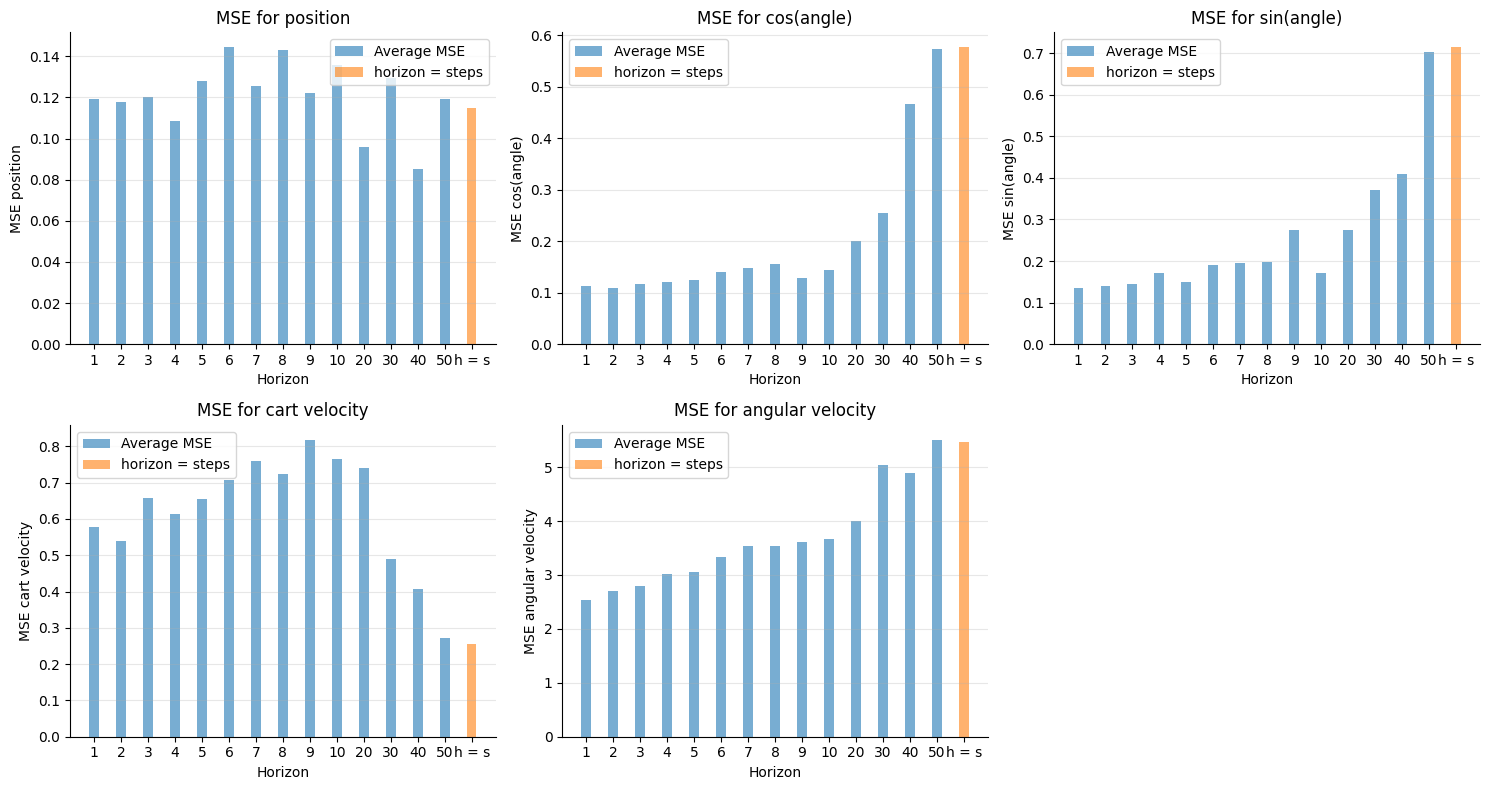

In [108]:
# Plot MSE as bar plot for each physical dimension
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    horizons_list = []
    mse_per_horizon_list = []

    for horizon in prediction_horizons:
        horizons_list.append(horizon)
        mse_per_horizon_list.append(
            metrics_by_horizon[horizon]['error_physical_per_dim'][dim])

    ax = axes[dim]

    # Get the single trajectory error for this dimension
    single_trajectory_error = results[(
        0, angle_to_analyze)]['error_physical_per_dim'][dim]

    # Create bar positions
    x = np.arange(len(horizons_list))
    width = 0.35

    # Plot bars for average MSE
    ax.bar(x, mse_per_horizon_list, width, label='Average MSE', alpha=0.6)

    # Plot single bar for single trajectory to the right
    ax.bar(len(horizons_list),
           single_trajectory_error,
           width,
           label='horizon = steps',
           alpha=0.6)

    ax.set_xlabel('Horizon')
    ax.set_ylabel(f'MSE {variable_names[dim]}')
    ax.set_title(f'MSE for {variable_names[dim]}')
    ax.set_xticks(list(x) + [len(horizons_list)])
    ax.set_xticklabels(horizons_list + ['h = s'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()


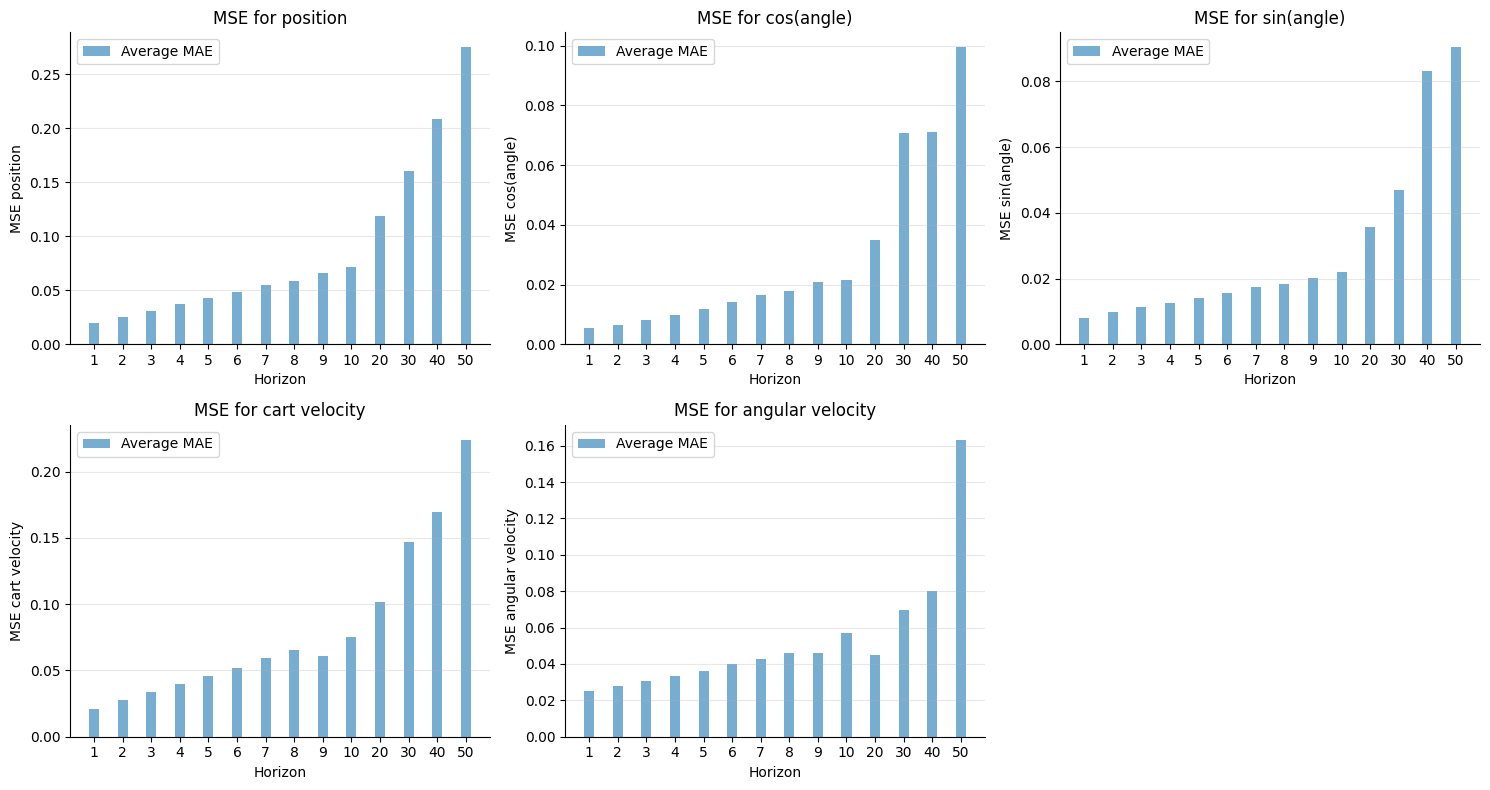

In [131]:
# Plot MSE as bar plot for each physical dimension
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    horizons_list = []
    mse_per_horizon_list = []

    for horizon in prediction_horizons:
        horizons_list.append(horizon)
        mse_per_horizon_list.append(
            metrics_by_horizon[horizon]['error_physical_per_dim'][dim])

    ax = axes[dim]

    # Create bar positions
    x = np.arange(len(horizons_list))
    width = 0.35

    # Plot bars for average MSE
    ax.bar(x, mse_per_horizon_list, width, label='Average MAE', alpha=0.6)

    ax.set_xlabel('Horizon')
    ax.set_ylabel(f'MSE {variable_names[dim]}')
    ax.set_title(f'MSE for {variable_names[dim]}')
    ax.set_xticks(list(x))
    ax.set_xticklabels(horizons_list)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()

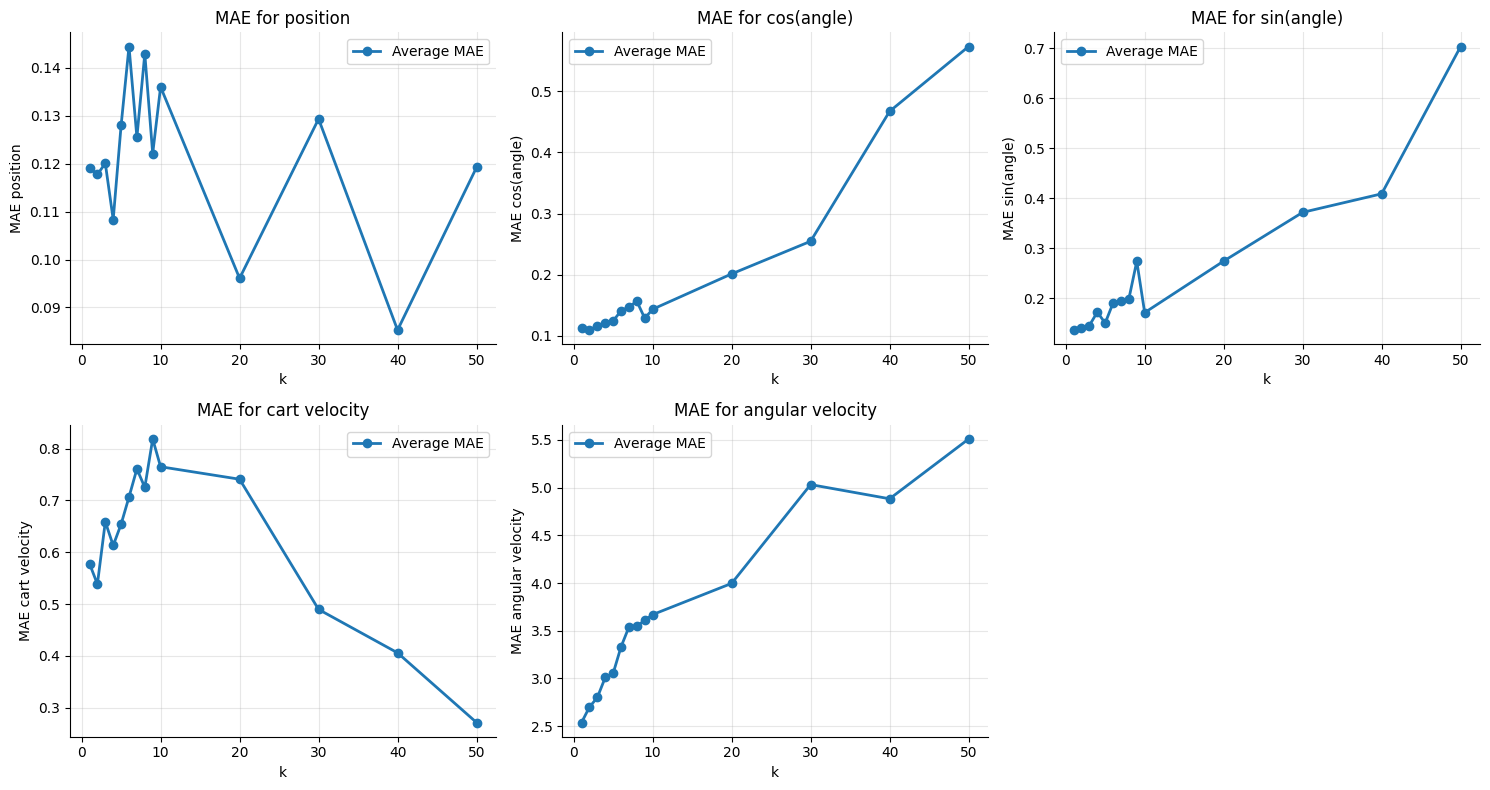

In [113]:
# Plot MSE as line plot for each physical dimension
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    horizons_list = []
    mse_per_horizon_list = []

    for horizon in prediction_horizons:
        horizons_list.append(horizon)
        mse_per_horizon_list.append(
            metrics_by_horizon[horizon]['error_physical_per_dim'][dim])

    ax = axes[dim]

    # Plot line for MSE
    ax.plot(horizons_list,
            mse_per_horizon_list,
            marker='o',
            linewidth=2,
            markersize=6,
            label='Average MAE')

    ax.set_xlabel('k')
    ax.set_ylabel(f'MAE {variable_names[dim]}')
    ax.set_title(f'MAE for {variable_names[dim]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()

In [111]:
horizon = 50
angle_to_show = 324
frames_predicted = reconstruct_cartpole_dmcontrol(
    results[(0, angle_to_show)][f'obs_predicted_steps_{horizon}'],
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

frames_true = reconstruct_cartpole_dmcontrol(
    results[(0, angle_to_show)][f'obs_true_state'],
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

100%|██████████| 50/50 [00:01<00:00, 47.60it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_20260119_193425.mp4


100%|██████████| 50/50 [00:01<00:00, 48.32it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_20260119_193426.mp4


In [112]:
# Create side-by-side video
import cv2
import imageio
# Get dimensions
height, width = frames_true[0].shape[:2]

# Create frames with side-by-side comparison
combined_frames = []
for frame_true, frame_pred in zip(frames_true, frames_predicted):
    # Create a canvas for side-by-side display with padding
    padding = 60
    combined = np.zeros((height + padding, width * 2 + 20, 3), dtype=np.uint8)

    # Add a subtle background for the title area
    combined[:padding, :] = (40, 40, 40)

    # Add titles with better positioning and styling
    # True trajectory title
    true_text = 'Ground Truth'
    true_text_size = cv2.getTextSize(true_text, cv2.FONT_HERSHEY_DUPLEX, 0.9,
                                     2)[0]
    true_x = (width - true_text_size[0]) // 2
    cv2.putText(combined, true_text, (true_x, 38), cv2.FONT_HERSHEY_DUPLEX, 0.9,
                (255, 255, 255), 2, cv2.LINE_AA)

    # Predicted trajectory title
    pred_text = 'Model Prediction'
    pred_text_size = cv2.getTextSize(pred_text, cv2.FONT_HERSHEY_DUPLEX, 0.9,
                                     2)[0]
    pred_x = width + 10 + (width - pred_text_size[0]) // 2
    cv2.putText(combined, pred_text, (pred_x, 38), cv2.FONT_HERSHEY_DUPLEX, 0.9,
                (255, 255, 255), 2, cv2.LINE_AA)

    # Add a separator line
    cv2.line(combined, (width + 10, padding), (width + 10, height + padding),
             (80, 80, 80), 2)

    # Place frames side by side
    combined[padding:, :width] = frame_true
    combined[padding:, width + 20:] = frame_pred

    combined_frames.append(combined)

# Save the combined video
video_path = f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/comparison_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
imageio.mimwrite(video_path, combined_frames, fps=30, macro_block_size=None)

print(
    f"Created side-by-side comparison video with {len(combined_frames)} frames at {video_path}"
)
len(frames_predicted)


Created side-by-side comparison video with 50 frames at /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/comparison_20260119_193429.mp4


[swscaler @ 0x6c7e680] Warning: data is not aligned! This can lead to a speed loss


50